In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# incarcam datele
df = pd.read_csv('data/Teen_Mental_Health_Dataset.csv')

# eliminam atributele stress_level, anxiety_level si addiction_level
df = df.drop(['stress_level', 'anxiety_level', 'addiction_level'], axis=1)

# transformam variabile text în numerice
def encode_text(df, columns):
    le = LabelEncoder()
    for col in columns:
        df[col] = le.fit_transform(df[col])
    return df

categoriale = ['gender', 'platform_usage', 'social_interaction_level']
df = encode_text(df, categoriale)

# separare X (atribute) si y (scop)
X = df.drop('depression_label', axis=1).values.astype(np.float32)
y = df['depression_label'].values.astype(np.float32)

# standardizam datele
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# functie pentru rularea experimentului
def experiment_perceptron(k_val, eta, max_it, early_st):
    print(f"\n{'='*30}")
    print(f"EXPERIMENT: K={k_val}, eta0={eta}, max_iter={max_it}")
    
    ppn = Perceptron(eta0=eta, max_iter=max_it, early_stopping=early_st, random_state=42)
    kf = KFold(n_splits=k_val, shuffle=True, random_state=42)
    
    # genera, predictiile prin Cross-Validation (K-Fold)
    y_pred = cross_val_predict(ppn, X_std, y, cv=kf)
    
    # calculam si afisam acuratetea
    acc = accuracy_score(y, y_pred)
    print(f"ACURATEȚE: {acc:.4f}")
    
    # afisam raportul de clasificare (precision, recall, F1-Score)
    print("\nRAPORT DE CLASIFICARE:")
    print(classification_report(y, y_pred))
    
    # calculam matricea de confuzie
    cm = confusion_matrix(y, y_pred)
    print("MATRICEA DE CONFUZIE:")
    print(cm)
    
    # partea de rapoarte
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    # matricea de confuzie (Heatmap)
    ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=ax[0], cmap='Blues')
    ax[0].set_title(f"Matrice Confuzie (K={k_val})")
    
    # comparare valori reale vs predicțti 
    # luam doar primele 50 de instante
    t = pd.DataFrame({'real': y[:50], 'predit': y_pred[:50]})
    ax[1].plot(t['real'].tolist(), label='Real', marker='o', linestyle='')
    ax[1].plot(t['predit'].tolist(), label='Predit', marker='x', linestyle='')
    ax[1].set_title("Real vs Predictie (esantion 50)")
    ax[1].legend()
    
    plt.tight_layout()
    plt.show()


EXPERIMENT: K=5, eta0=0.01, max_iter=100
ACURATEȚE: 0.9542

RAPORT DE CLASIFICARE:
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98      1169
         1.0       0.10      0.10      0.10        31

    accuracy                           0.95      1200
   macro avg       0.54      0.54      0.54      1200
weighted avg       0.95      0.95      0.95      1200

MATRICEA DE CONFUZIE:
[[1142   27]
 [  28    3]]


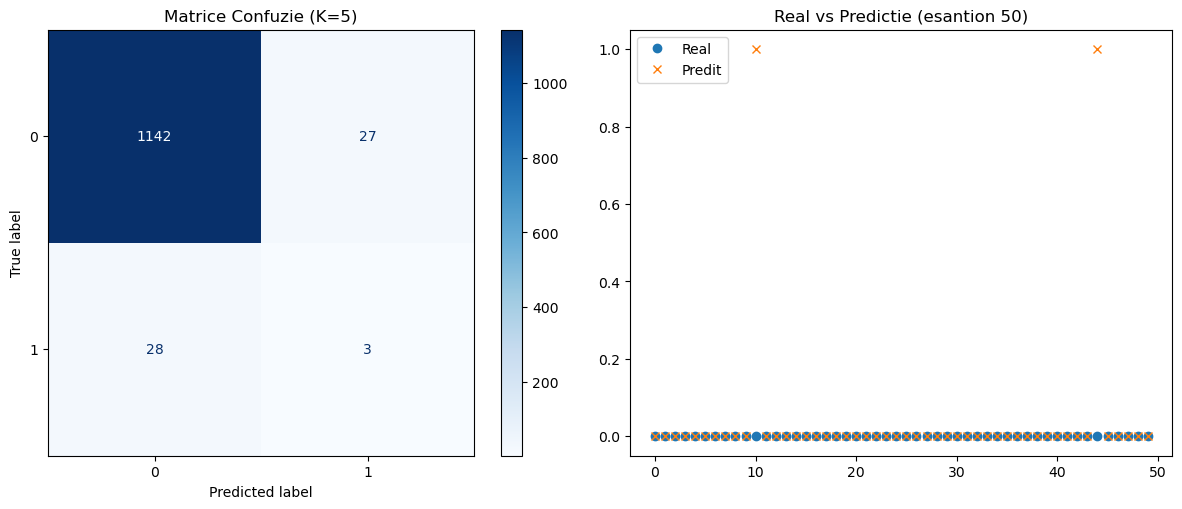

In [11]:
# experimentul 1
experiment_perceptron(k_val=5, eta=0.01, max_it=100, early_st=False)


EXPERIMENT: K=5, eta0=0.1, max_iter=100
ACURATEȚE: 0.9550

RAPORT DE CLASIFICARE:
              precision    recall  f1-score   support

         0.0       0.97      0.98      0.98      1169
         1.0       0.00      0.00      0.00        31

    accuracy                           0.95      1200
   macro avg       0.49      0.49      0.49      1200
weighted avg       0.95      0.95      0.95      1200

MATRICEA DE CONFUZIE:
[[1146   23]
 [  31    0]]


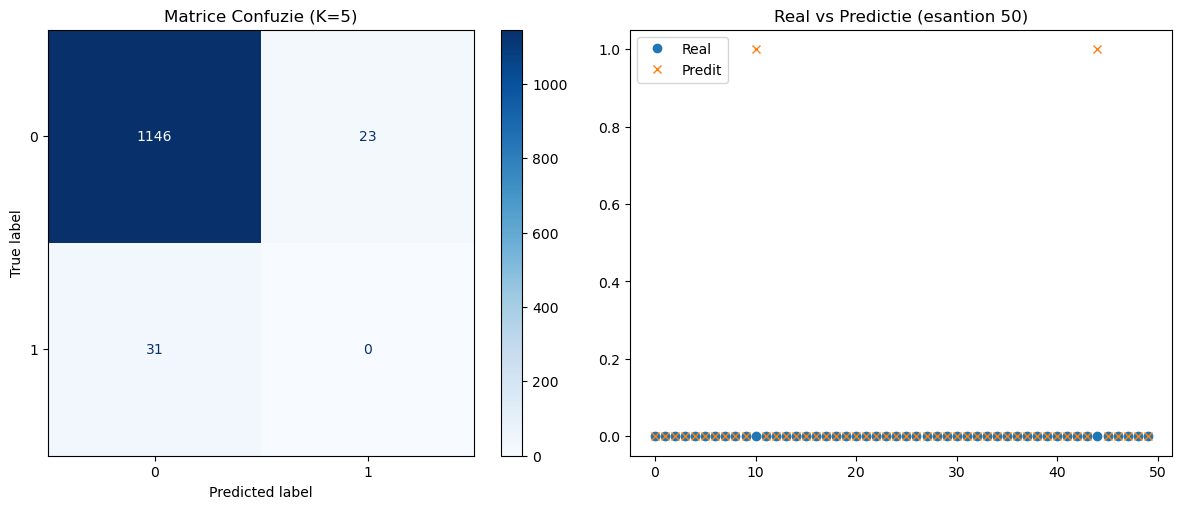

In [12]:
# experimentul 2
experiment_perceptron(k_val=5, eta=0.1, max_it=100, early_st=False)


EXPERIMENT: K=5, eta0=0.01, max_iter=1000
ACURATEȚE: 0.9542

RAPORT DE CLASIFICARE:
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98      1169
         1.0       0.10      0.10      0.10        31

    accuracy                           0.95      1200
   macro avg       0.54      0.54      0.54      1200
weighted avg       0.95      0.95      0.95      1200

MATRICEA DE CONFUZIE:
[[1142   27]
 [  28    3]]


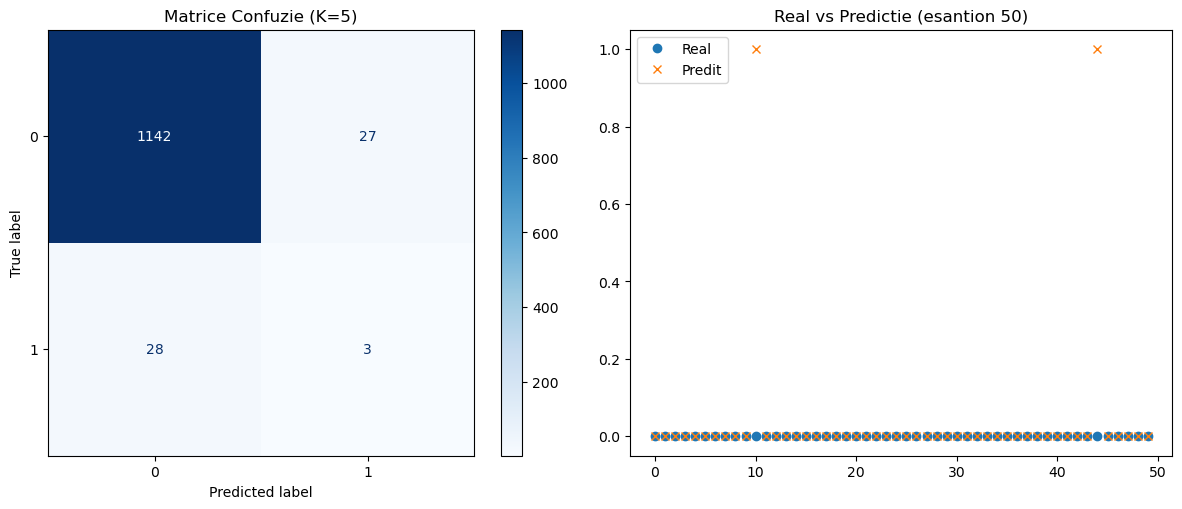

In [13]:
# experimentul 3
experiment_perceptron(k_val=5, eta=0.01, max_it=1000, early_st=False)


EXPERIMENT: K=5, eta0=0.01, max_iter=100
ACURATEȚE: 0.9575

RAPORT DE CLASIFICARE:
              precision    recall  f1-score   support

         0.0       0.97      0.98      0.98      1169
         1.0       0.00      0.00      0.00        31

    accuracy                           0.96      1200
   macro avg       0.49      0.49      0.49      1200
weighted avg       0.95      0.96      0.95      1200

MATRICEA DE CONFUZIE:
[[1149   20]
 [  31    0]]


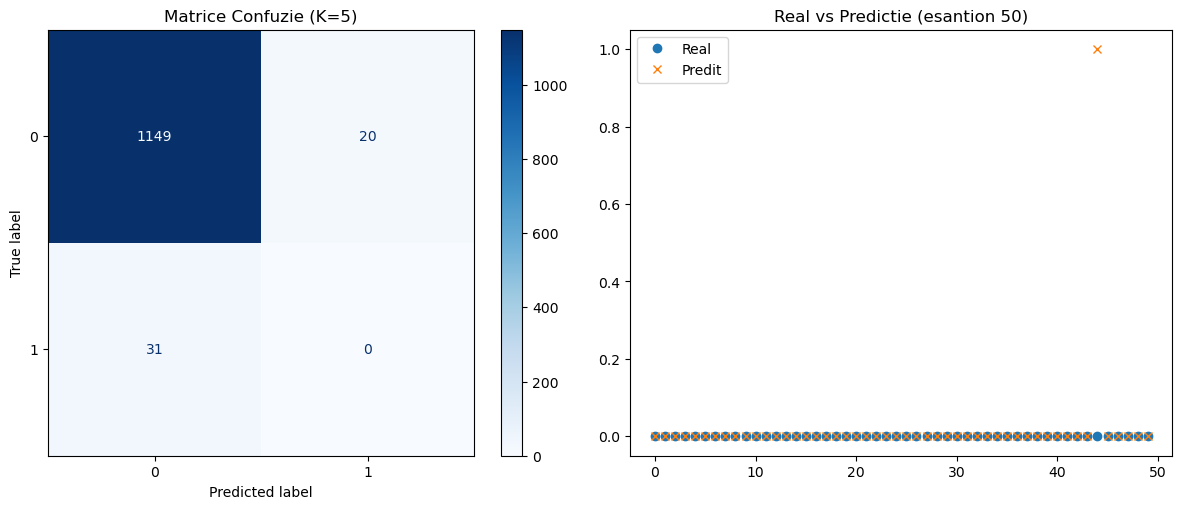

In [14]:
# experimentul 4
experiment_perceptron(k_val=5, eta=0.01, max_it=100, early_st=True)


EXPERIMENT: K=10, eta0=0.01, max_iter=100
ACURATEȚE: 0.9450

RAPORT DE CLASIFICARE:
              precision    recall  f1-score   support

         0.0       0.98      0.97      0.97      1169
         1.0       0.05      0.06      0.06        31

    accuracy                           0.94      1200
   macro avg       0.51      0.52      0.51      1200
weighted avg       0.95      0.94      0.95      1200

MATRICEA DE CONFUZIE:
[[1132   37]
 [  29    2]]


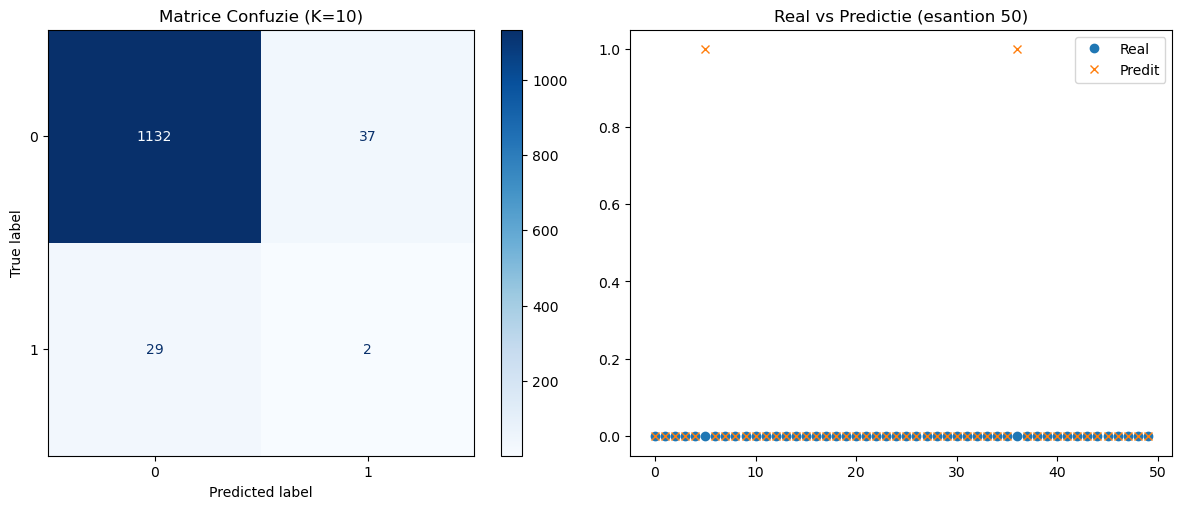

In [15]:
# experimentul 5
experiment_perceptron(k_val=10, eta=0.01, max_it=100, early_st=False)